In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
%matplotlib inline

# -- Параметры анализа --

# Даты
end_date = datetime.now()
start_date = end_date - timedelta(days=10*365) # Примерно 10 лет

# Тикеры (используем ETF для простоты бэктеста)
# SPY: S&P 500 ETF
# GLD: Gold ETF
# FXE: Euro ETF
tickers = ['SPY', 'GLD', 'FXE']

# Начальный капитал (USD)
initial_capital = 100000.0

# Целевые веса портфеля
target_weights = {'SPY': 0.30, 'GLD': 0.30, 'FXE': 0.20, 'Cash': 0.20}

# Частота ребалансировки (Pandas Offset Alias)
# 'M': каждый месяц (конец)
rebalance_freq = 'M'

print("Параметры заданы:")
print(f"Start Date: {start_date.strftime('%Y-%m-%d')}")
print(f"End Date: {end_date.strftime('%Y-%m-%d')}")
print(f"Tickers: {tickers}")
print(f"Initial Capital: ${initial_capital:,.2f}")
print(f"Target Weights: {target_weights}")
print(f"Rebalance Freq: {rebalance_freq}")


Параметры заданы:
Start Date: 2015-12-25
End Date: 2025-12-22
Tickers: ['SPY', 'GLD', 'FXE']
Initial Capital: $100,000.00
Target Weights: {'SPY': 0.3, 'GLD': 0.3, 'FXE': 0.2, 'Cash': 0.2}
Rebalance Freq: M


In [2]:
# Загрузка исторических данных
print(f"Загрузка данных для {tickers}...")
try:
    # Используем Close вместо Adj Close
    raw_data = yf.download(tickers, start=start_date, end=end_date)
    data = raw_data['Close'] # Используем Close вместо Adj Close
    data.dropna(inplace=True) # Удаляем строки с NaN, если есть пропуски по одному из тикеров
    print("Данные успешно загружены.")
    print("Размер данных:", data.shape)
    print("Последние 5 строк:")
    display(data.tail())
except Exception as e:
    print(f"Ошибка при загрузке данных: {e}")

# Добавляем столбец для 'Cash' (цена всегда 1)
if 'data' in locals() and isinstance(data, pd.DataFrame):
    data['Cash'] = 1.0
else:
    print("Переменная 'data' не определена или не DataFrame, столбец 'Cash' не добавлен.")


Загрузка данных для ['SPY', 'GLD', 'FXE']...


/var/folders/jm/cj2_fkqx281f_phyqkcgvswh0000gn/T/ipykernel_9423/2453214546.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download(tickers, start=start_date, end=end_date)
[*********************100%***********************]  3 of 3 completed

Данные успешно загружены.
Размер данных: (2511, 3)
Последние 5 строк:



/var/folders/jm/cj2_fkqx281f_phyqkcgvswh0000gn/T/ipykernel_9423/2453214546.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.dropna(inplace=True) # Удаляем строки с NaN, если есть пропуски по одному из тикеров


Ticker,FXE,GLD,SPY
Date,,,
2025-12-15,108.440002,395.799988,678.724426
2025-12-16,108.389999,395.890015,676.869934
2025-12-17,108.330002,399.290009,669.421936
2025-12-18,108.150002,398.570007,674.476929
2025-12-19,108.050003,399.019989,680.590027


/var/folders/jm/cj2_fkqx281f_phyqkcgvswh0000gn/T/ipykernel_9423/2453214546.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Cash'] = 1.0


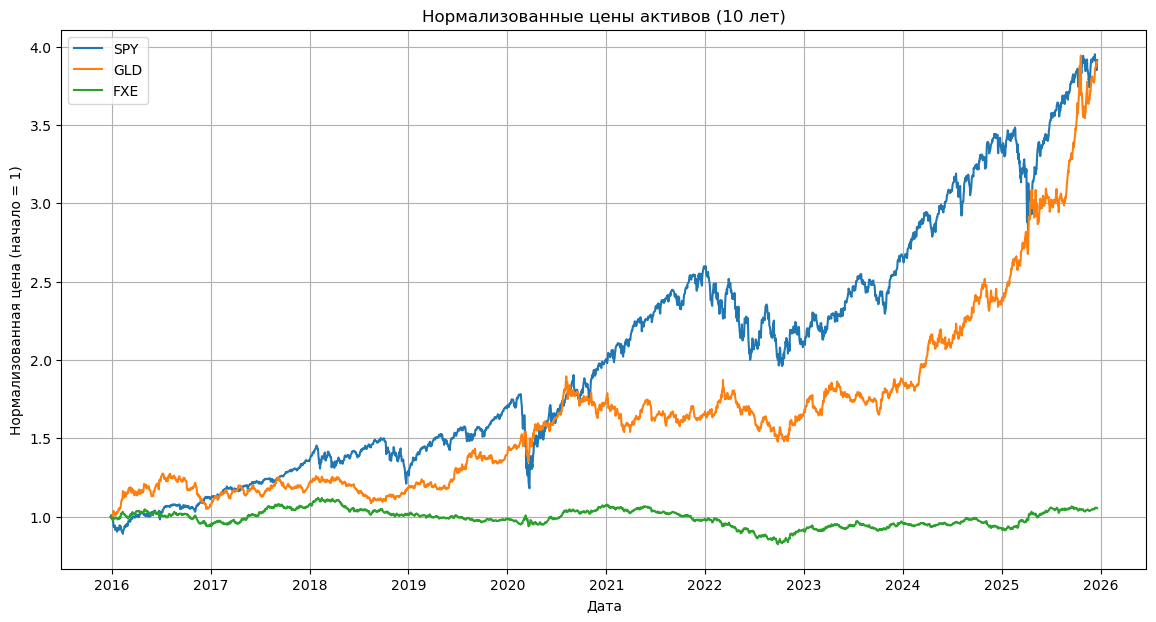

In [3]:
# Визуализация нормализованных цен
if 'data' in locals() and isinstance(data, pd.DataFrame) and not data.empty:
    # Нормализуем цены (начальная цена = 1)
    normalized_data = data[tickers].copy() # Без 'Cash'
    normalized_data = normalized_data / normalized_data.iloc[0]

    plt.figure(figsize=(14, 7))
    for ticker in normalized_data.columns:
        plt.plot(normalized_data.index, normalized_data[ticker], label=ticker)

    plt.title('Нормализованные цены активов (10 лет)')
    plt.xlabel('Дата')
    plt.ylabel('Нормализованная цена (начало = 1)')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("Нет данных для отображения.")



In [4]:
# Подготовка к бэктестингу

if 'data' in locals() and isinstance(data, pd.DataFrame) and not data.empty:
    # 1. Определяем даты ребалансировки
    first_date = data.index[0]
    # Используем rebalance_freq как и раньше
    # Если rebalance_freq == 'M', то заменим его здесь для date_range
    # Если rebalance_freq != 'M', то заменим его здесь для freq_to_use
    freq_to_use = rebalance_freq if rebalance_freq != 'M' else 'ME'
    rebalance_dates = pd.date_range(start=first_date, end=data.index[-1], freq=freq_to_use)
    rebalance_dates_aligned = data.index.searchsorted(rebalance_dates, side='left')
    rebalance_dates_aligned = np.unique(rebalance_dates_aligned)
    rebalance_dates_aligned = rebalance_dates_aligned[rebalance_dates_aligned < len(data.index)]
    actual_rebalance_dates = data.index[rebalance_dates_aligned]

    print(f"Найдено {len(actual_rebalance_dates)} дат ребалансировки.")

    # 2. Инициализация портфеля
    portfolio = pd.DataFrame(index=data.index, columns=tickers + ['Cash', 'Holdings', 'Asset_Values', 'Total_Value'])
    first_index = portfolio.index[0] # Получаем первый индекс
    # Используем .loc для скаляров (убирает FutureWarning)
    portfolio.loc[first_index, 'Cash'] = initial_capital
    portfolio.loc[first_index, 'Total_Value'] = initial_capital
    # Используем .at для словарей (исправляет ValueError)
    portfolio.at[first_index, 'Holdings'] = {ticker: 0.0 for ticker in tickers} # Используем float для долей
    portfolio.at[first_index, 'Asset_Values'] = {ticker: 0.0 for ticker in tickers}
    first_rebalance_done = False
    print("Структуры данных для портфеля инициализированы.")
else:
    print("Нет данных для подготовки бэктеста.")


Найдено 120 дат ребалансировки.
Структуры данных для портфеля инициализированы.


In [5]:
# Цикл бэктестинга и ребалансировки

if 'portfolio' in locals() and isinstance(portfolio, pd.DataFrame):
    print("Запуск цикла бэктестинга...")

    for i in range(1, len(portfolio.index)):
        current_date = portfolio.index[i]
        prev_date = portfolio.index[i-1]

        # Переносим состояние портфеля с предыдущего дня
        portfolio.at[current_date, 'Holdings'] = portfolio.at[prev_date, 'Holdings'].copy()
        portfolio.at[current_date, 'Cash'] = portfolio.at[prev_date, 'Cash']

        # Обновляем стоимость активов на основе новых цен
        current_asset_values = {}
        total_asset_value = 0.0
        holdings_dict = portfolio.at[current_date, 'Holdings']
        if isinstance(holdings_dict, dict):
            for ticker in tickers:
                shares = holdings_dict.get(ticker, 0.0)
                current_price = data.at[current_date, ticker]
                value = shares * current_price
                current_asset_values[ticker] = value
                total_asset_value += value
                # --- Записываем стоимость актива в соответствующую колонку --- 
                portfolio.at[current_date, ticker] = value 
        else:
            for ticker in tickers:
                 current_asset_values[ticker] = 0.0
                 # --- Записываем 0, если Holdings еще не инициализирован --- 
                 portfolio.at[current_date, ticker] = 0.0

        portfolio.at[current_date, 'Asset_Values'] = current_asset_values
        portfolio.at[current_date, 'Total_Value'] = total_asset_value + portfolio.at[current_date, 'Cash']

        # Проверяем, нужно ли ребалансировать (включая самый первый день)
        if not first_rebalance_done or current_date in actual_rebalance_dates:
            current_total_value = portfolio.at[current_date, 'Total_Value']
            new_holdings = {}
            # Этот блок ниже перезапишет значения тикеров после ребалансировки
            cash_before_rebalance_calc = portfolio.at[current_date, 'Cash']
            invested_value_target = 0.0

            for ticker in tickers:
                target_value = current_total_value * target_weights[ticker]
                current_price = data.at[current_date, ticker]
                if current_price > 0:
                    shares = target_value / current_price
                    new_holdings[ticker] = shares
                    # --- Перезаписываем стоимость тикера после ребалансировки --- 
                    portfolio.at[current_date, ticker] = target_value
                    invested_value_target += target_value # Суммируем целевые стоимости
                else:
                    new_holdings[ticker] = 0.0
                    # --- Перезаписываем стоимость тикера (0) --- 
                    portfolio.at[current_date, ticker] = 0.0
            
            # Старая логика расчета cash_after_rebalance иногда неточна из-за округлений
            # invested_value = sum(new_holdings[ticker] * data.at[current_date, ticker] for ticker in tickers)
            # cash_after_rebalance = current_total_value - invested_value
            # Используем расчет на основе целевой доли Cash
            cash_after_rebalance = current_total_value * target_weights.get('Cash', 0.0)

            # Обновляем портфель
            portfolio.at[current_date, 'Holdings'] = new_holdings
            portfolio.at[current_date, 'Cash'] = cash_after_rebalance
            
            # Пересчитываем Asset_Values для точности после ребалансировки
            rebalanced_asset_values = {ticker: portfolio.at[current_date, ticker] for ticker in tickers}
            portfolio.at[current_date, 'Asset_Values'] = rebalanced_asset_values
            # Пересчитываем Total_Value для точности
            portfolio.at[current_date, 'Total_Value'] = sum(rebalanced_asset_values.values()) + cash_after_rebalance

            if not first_rebalance_done:
                 first_rebalance_done = True

    print("Цикл бэктестинга завершен.")
    print() # Пустая строка для разделения
    print('Последнее состояние портфеля:')
    display(portfolio.tail())
else:
    print("Не могу запустить бэктест, портфель не инициализирован или не DataFrame.")


Запуск цикла бэктестинга...
Цикл бэктестинга завершен.

Последнее состояние портфеля:


,SPY,GLD,FXE,Cash,Holdings,Asset_Values,Total_Value
Date,,,,,,,
2025-12-15,71011.287183,72064.849333,47914.205209,47308.869621,"{'SPY': 104.62462294702863, 'GLD': 182.0739048...","{'SPY': 71011.28718338803, 'GLD': 72064.849332...",238299.211346
2025-12-16,70817.261638,72081.240874,47892.111366,47308.869621,"{'SPY': 104.62462294702863, 'GLD': 182.0739048...","{'SPY': 70817.26163751264, 'GLD': 72081.240874...",238099.483498
2025-12-17,70038.01765,72700.291039,47865.60145,47308.869621,"{'SPY': 104.62462294702863, 'GLD': 182.0739048...","{'SPY': 70038.01765014813, 'GLD': 72700.291039...",237912.77976
2025-12-18,70566.894353,72569.197606,47786.068331,47308.869621,"{'SPY': 104.62462294702863, 'GLD': 182.0739048...","{'SPY': 70566.89435285174, 'GLD': 72569.197605...",238231.02991
2025-12-19,71206.474941,72651.127529,47741.884015,47308.869621,"{'SPY': 104.62462294702863, 'GLD': 182.0739048...","{'SPY': 71206.4749412615, 'GLD': 72651.1275289...",238908.356105


Максимальная просадка (Ребалансировка): -13.79%


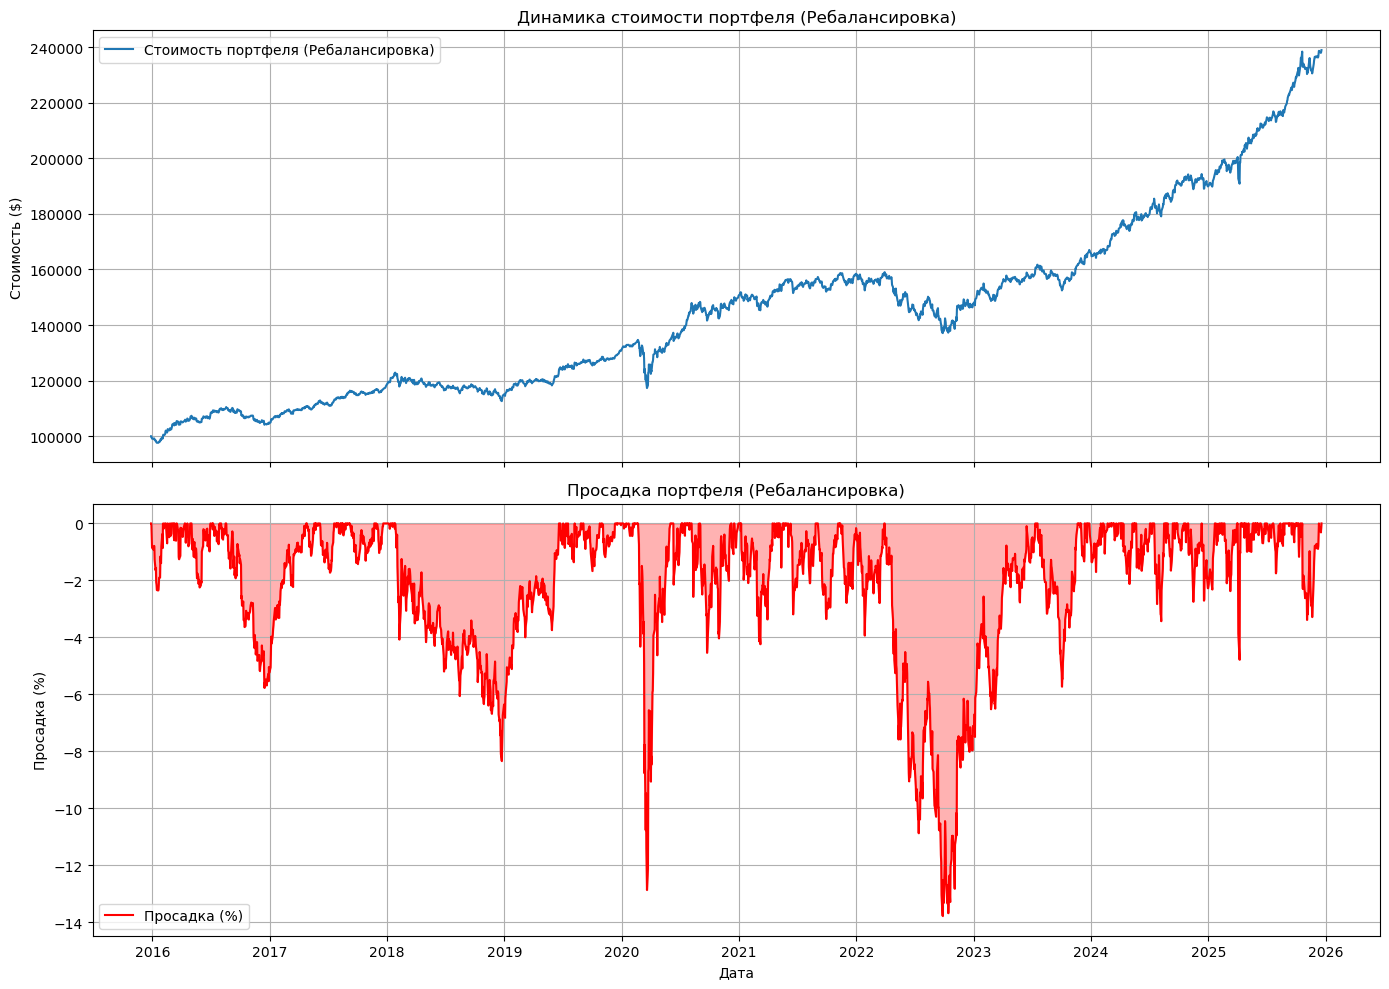

In [6]:
# Расчет максимальной просадки (Max Drawdown) для ребалансированного портфеля
max_drawdown_rebalanced = np.nan # Инициализация
cumulative_max = None # Инициализация
drawdown = None # Инициализация

if 'portfolio' in locals() and isinstance(portfolio, pd.DataFrame) and 'Total_Value' in portfolio.columns:
    # Принудительно конвертируем в float и удаляем NaN
    portfolio_values = pd.to_numeric(portfolio['Total_Value'], errors='coerce').dropna()
    
    if not portfolio_values.empty:
        cumulative_max = portfolio_values.cummax()
        # Избегаем деления на 0, заменяя 0 на NaN перед делением
        cumulative_max_safe = cumulative_max.replace(0, np.nan) 
        drawdown = (portfolio_values - cumulative_max_safe) / cumulative_max_safe
        
        # Принудительно конвертируем drawdown в числовой формат, ошибки в NaN
        drawdown = pd.to_numeric(drawdown, errors='coerce')

        # Проверяем, удался ли расчет drawdown
        if drawdown is not None and not drawdown.isna().all(): # Не все значения NaN?
             max_drawdown_rebalanced = drawdown.min()
             print(f"Максимальная просадка (Ребалансировка): {max_drawdown_rebalanced:.2%}")
             
             # --- Построение графика --- 
             try:
                 fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
                 
                 # График стоимости портфеля
                 ax1.plot(portfolio_values.index, portfolio_values, label='Стоимость портфеля (Ребалансировка)')
                 ax1.set_title('Динамика стоимости портфеля (Ребалансировка)')
                 ax1.set_ylabel('Стоимость ($)')
                 ax1.grid(True); ax1.legend()
                 
                 # График просадки (линия)
                 # Для линии можно заполнить NaN, чтобы не было разрывов, если нужно
                 # drawdown_for_plot = drawdown.fillna(method='ffill').fillna(0) 
                 ax2.plot(drawdown.index, drawdown * 100, label='Просадка (%)', color='red') 
                 
                 # Заливка области просадки (с обработкой NaN)
                 ax2.fill_between(drawdown.index, drawdown * 100, 0, where=drawdown.notna(), color='red', alpha=0.3, interpolate=True)
                 
                 ax2.set_title('Просадка портфеля (Ребалансировка)')
                 ax2.set_xlabel('Дата'); ax2.set_ylabel('Просадка (%)')
                 ax2.grid(True); ax2.legend()
                 plt.tight_layout(); plt.show()
                 
             except Exception as plot_err:
                 print(f"Ошибка при построении графика просадки: {plot_err}")
        else:
             print("Расчет просадки не удался (возможно, все значения NaN).")
             # Убедимся, что max_drawdown_rebalanced остался NaN
             max_drawdown_rebalanced = np.nan 

    else:
        print("Нет данных о стоимости портфеля (после конвертации/dropna) для расчета просадки.")
else:
    print("Портфель не рассчитан или не DataFrame.")



Расчет Buy & Hold...
Buy & Hold SPY - Final Value: $391,316.06, Max Drawdown: -33.72%
Buy & Hold GLD - Final Value: $390,163.30, Max Drawdown: -22.00%


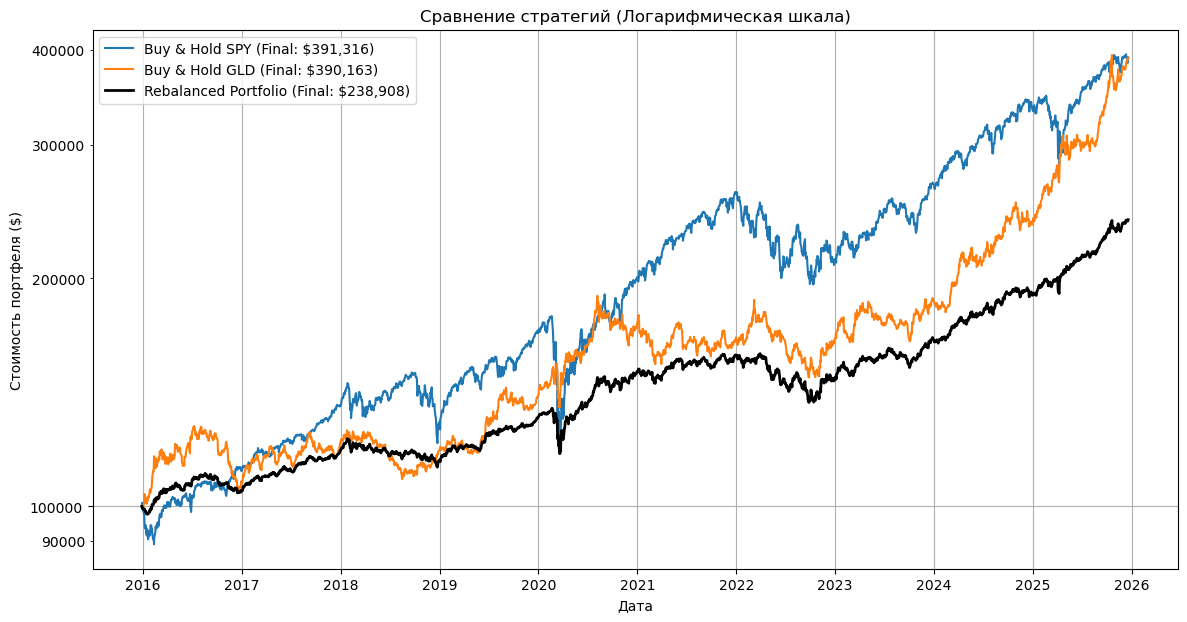

In [7]:
# Расчет стратегий Buy & Hold для SPY и GLD
import matplotlib.ticker as mticker

spy_final_value, spy_max_drawdown = np.nan, np.nan
gld_final_value, gld_max_drawdown = np.nan, np.nan
spy_bh_value, gld_bh_value = None, None # Инициализация для графика
spy_cummax, gld_cummax = None, None # Инициализация для RF
spy_drawdown, gld_drawdown = None, None # Инициализация для RF

if 'data' in locals() and isinstance(data, pd.DataFrame) and not data.empty:
    print()
    print("Расчет Buy & Hold...")

    # SPY B&H
    if 'SPY' in data.columns:
        spy_data = data['SPY'].dropna()
        if not spy_data.empty and spy_data.iloc[0] > 0:
            spy_shares = initial_capital / spy_data.iloc[0]
            spy_bh_value = spy_shares * spy_data
            spy_cummax = spy_bh_value.cummax()
            spy_drawdown = (spy_bh_value - spy_cummax) / spy_cummax
            spy_max_drawdown = spy_drawdown.min()
            spy_final_value = spy_bh_value.iloc[-1]
            print(f"Buy & Hold SPY - Final Value: ${spy_final_value:,.2f}, Max Drawdown: {spy_max_drawdown:.2%}")
        else: print("Нет данных SPY для B&H или начальная цена 0.")
    else: print("Колонка SPY отсутствует.")

    # GLD B&H
    if 'GLD' in data.columns:
        gld_data = data['GLD'].dropna()
        if not gld_data.empty and gld_data.iloc[0] > 0:
            gld_shares = initial_capital / gld_data.iloc[0]
            gld_bh_value = gld_shares * gld_data
            gld_cummax = gld_bh_value.cummax()
            gld_drawdown = (gld_bh_value - gld_cummax) / gld_cummax
            gld_max_drawdown = gld_drawdown.min()
            gld_final_value = gld_bh_value.iloc[-1]
            print(f"Buy & Hold GLD - Final Value: ${gld_final_value:,.2f}, Max Drawdown: {gld_max_drawdown:.2%}")
        else: print("Нет данных GLD для B&H или начальная цена 0.")
    else: print("Колонка GLD отсутствует.")

    # Визуализация B&H
    plt.figure(figsize=(14, 7))
    plot_exists = False
    if 'spy_bh_value' in locals() and isinstance(spy_bh_value, pd.Series):
        plt.plot(spy_bh_value.index, spy_bh_value, label=f'Buy & Hold SPY (Final: ${spy_final_value:,.0f})')
        plot_exists = True
    if 'gld_bh_value' in locals() and isinstance(gld_bh_value, pd.Series):
         plt.plot(gld_bh_value.index, gld_bh_value, label=f'Buy & Hold GLD (Final: ${gld_final_value:,.0f})')
         plot_exists = True
    if 'portfolio_values' in locals() and isinstance(portfolio_values, pd.Series):
        rebalanced_final_value = portfolio_values.iloc[-1]
        plt.plot(portfolio_values.index, portfolio_values, label=f'Rebalanced Portfolio (Final: ${rebalanced_final_value:,.0f})', linewidth=2, color='black')
        plot_exists = True

    if plot_exists:
        plt.title('Сравнение стратегий (Логарифмическая шкала)')
        plt.xlabel('Дата'); plt.ylabel('Стоимость портфеля ($)')
        plt.yscale('log') # Применяем логарифмическую шкалу
        
        # --- Форматирование оси Y --- 
        ax = plt.gca() # Получаем текущие оси
        # Используем FormatStrFormatter для явного указания формата без научной нотации
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f')) 
        # Попробуем отформатировать и минорные тики, если они видны
        ax.yaxis.set_minor_formatter(mticker.FormatStrFormatter('%.0f')) 
        # Важно: grid() и legend() лучше вызывать после форматирования для корректного отображения
        plt.legend(); plt.grid(True); 
        plt.show()
    else:
        print("Нет данных для построения графика сравнения стратегий.")

else:
    print("Нет данных для расчета Buy & Hold.")


In [8]:
# Расчет Фактора Восстановления (Recovery Factor)

print() # Пустая строка
print("Расчет Фактора Восстановления...")
results = {}

# Rebalanced Portfolio
if ('portfolio_values' in locals() and isinstance(portfolio_values, pd.Series) and not portfolio_values.empty and
    'max_drawdown_rebalanced' in locals() and not pd.isna(max_drawdown_rebalanced) and
    'cumulative_max' in locals() and isinstance(cumulative_max, pd.Series) and
    'drawdown' in locals() and isinstance(drawdown, pd.Series)): # Доп. проверки

    total_profit_rebalanced = portfolio_values.iloc[-1] - initial_capital
    if max_drawdown_rebalanced != 0 and not drawdown.empty:
         try:
             # Используем абсолютную просадку в деньгах, нормированную на пик перед макс. просадкой
             peak_before_max_drawdown = cumulative_max.loc[drawdown.idxmin()] # Используем loc для DatetimeIndex
             recovery_factor_rebalanced = total_profit_rebalanced / abs(max_drawdown_rebalanced * peak_before_max_drawdown)
             print(f"Rebalanced Portfolio - Total Profit: ${total_profit_rebalanced:,.2f}, Recovery Factor: {recovery_factor_rebalanced:.2f}")
             results['Rebalanced'] = {'Final Value': portfolio_values.iloc[-1], 'Max Drawdown (%)': max_drawdown_rebalanced * 100, 'Recovery Factor': recovery_factor_rebalanced}
         except (IndexError, KeyError) as e: # Ловим KeyError тоже, т.к. idxmin может вернуть дату не из индекса cumulative_max
             print(f"Rebalanced Portfolio - Ошибка при расчете RF (Index/KeyError): {e}. Возможно, пустой drawdown или несовпадение индексов.")
             results['Rebalanced'] = {'Final Value': portfolio_values.iloc[-1], 'Max Drawdown (%)': max_drawdown_rebalanced * 100, 'Recovery Factor': np.nan}
    else:
        print("Rebalanced Portfolio - Max Drawdown is zero or drawdown is empty, Recovery Factor is undefined.")
        results['Rebalanced'] = {'Final Value': portfolio_values.iloc[-1], 'Max Drawdown (%)': 0, 'Recovery Factor': np.inf}
else:
    print("Нет данных для расчета RF ребалансированного портфеля.")

# SPY Buy & Hold
if ('spy_final_value' in locals() and not pd.isna(spy_final_value) and
    'spy_max_drawdown' in locals() and not pd.isna(spy_max_drawdown) and
    'spy_cummax' in locals() and isinstance(spy_cummax, pd.Series) and
    'spy_drawdown' in locals() and isinstance(spy_drawdown, pd.Series)): # Доп. проверки

    total_profit_spy = spy_final_value - initial_capital
    if spy_max_drawdown != 0 and not spy_drawdown.empty:
        try:
            peak_before_max_drawdown_spy = spy_cummax.loc[spy_drawdown.idxmin()]
            recovery_factor_spy = total_profit_spy / abs(spy_max_drawdown * peak_before_max_drawdown_spy)
            print(f"SPY Buy & Hold - Total Profit: ${total_profit_spy:,.2f}, Recovery Factor: {recovery_factor_spy:.2f}")
            results['SPY B&H'] = {'Final Value': spy_final_value, 'Max Drawdown (%)': spy_max_drawdown * 100, 'Recovery Factor': recovery_factor_spy}
        except (IndexError, KeyError) as e:
             print(f"SPY Buy & Hold - Ошибка при расчете RF (Index/KeyError): {e}. Возможно, пустой drawdown или несовпадение индексов.")
             results['SPY B&H'] = {'Final Value': spy_final_value, 'Max Drawdown (%)': spy_max_drawdown * 100, 'Recovery Factor': np.nan}
    else:
         print("SPY Buy & Hold - Max Drawdown is zero or drawdown is empty, Recovery Factor is undefined.")
         results['SPY B&H'] = {'Final Value': spy_final_value, 'Max Drawdown (%)': 0, 'Recovery Factor': np.inf}
else:
     print("Нет данных для расчета RF SPY B&H.")

# GLD Buy & Hold
if ('gld_final_value' in locals() and not pd.isna(gld_final_value) and
    'gld_max_drawdown' in locals() and not pd.isna(gld_max_drawdown) and
    'gld_cummax' in locals() and isinstance(gld_cummax, pd.Series) and
    'gld_drawdown' in locals() and isinstance(gld_drawdown, pd.Series)): # Доп. проверки

    total_profit_gld = gld_final_value - initial_capital
    if gld_max_drawdown != 0 and not gld_drawdown.empty:
        try:
            peak_before_max_drawdown_gld = gld_cummax.loc[gld_drawdown.idxmin()]
            recovery_factor_gld = total_profit_gld / abs(gld_max_drawdown * peak_before_max_drawdown_gld)
            print(f"GLD Buy & Hold - Total Profit: ${total_profit_gld:,.2f}, Recovery Factor: {recovery_factor_gld:.2f}")
            results['GLD B&H'] = {'Final Value': gld_final_value, 'Max Drawdown (%)': gld_max_drawdown * 100, 'Recovery Factor': recovery_factor_gld}
        except (IndexError, KeyError) as e:
             print(f"GLD Buy & Hold - Ошибка при расчете RF (Index/KeyError): {e}. Возможно, пустой drawdown или несовпадение индексов.")
             results['GLD B&H'] = {'Final Value': gld_final_value, 'Max Drawdown (%)': gld_max_drawdown * 100, 'Recovery Factor': np.nan}
    else:
        print("GLD Buy & Hold - Max Drawdown is zero or drawdown is empty, Recovery Factor is undefined.")
        results['GLD B&H'] = {'Final Value': gld_final_value, 'Max Drawdown (%)': 0, 'Recovery Factor': np.inf}
else:
    print("Нет данных для расчета RF GLD B&H.")




Расчет Фактора Восстановления...
Rebalanced Portfolio - Total Profit: $138,908.36, Recovery Factor: 6.34
SPY Buy & Hold - Total Profit: $291,316.06, Recovery Factor: 4.85
GLD Buy & Hold - Total Profit: $290,163.30, Recovery Factor: 6.96


In [9]:
# Итоговые результаты

print() # Пустая строка
print("--- Итоговые результаты ---")

if 'results' in locals() and results:
    results_df = pd.DataFrame.from_dict(results, orient='index')
    # Применяем форматирование с lambda только если колонка существует
    if 'Final Value' in results_df.columns:
        results_df['Final Value'] = results_df['Final Value'].map(lambda x: '${:,.2f}'.format(x) if pd.notna(x) else 'N/A')
    if 'Max Drawdown (%)' in results_df.columns:
        results_df['Max Drawdown (%)'] = results_df['Max Drawdown (%)'].map(lambda x: '{:.2f}%'.format(x) if pd.notna(x) else 'N/A')
    if 'Recovery Factor' in results_df.columns:
        results_df['Recovery Factor'] = results_df['Recovery Factor'].map(lambda x: '{:.2f}'.format(x) if pd.notna(x) and np.isfinite(x) else ('Inf' if x == np.inf else 'N/A'))

    display(results_df)
else:
    print("Нет результатов для отображения.")




--- Итоговые результаты ---


,Final Value,Max Drawdown (%),Recovery Factor
Rebalanced,"$238,908.36",-13.79%,6.34
SPY B&H,"$391,316.06",-33.72%,4.85
GLD B&H,"$390,163.30",-22.00%,6.96
